# 第2章 感知机 (Perceptron)

- 📅 2026-07-11
- 🏷️ 深度学习, 神经网络基础, 感知机
- 📖 参考：《深度学习入门：基于Python的理论与实现》斋藤康毅

## 2.1 感知机是什么

感知机（Perceptron）是由美国学者 Frank Rosenblatt 在 1957 年提出的算法。

**感知机接收多个输入信号，输出一个信号。** 信号只有 0（不传递）或 1（传递）两种取值。

```
    x1 ──→ (w1) ↘
                  Σ → θ → y
    x2 ──→ (w2) ↗

    x1, x2 : 输入信号
    w1, w2 : 权重（weight）
    θ      : 阈值（theta）
    y      : 输出信号
```

**数学公式（原始形式）：**

$$y = \begin{cases} 0 & (w_1x_1 + w_2x_2 \leq \theta) \\ 1 & (w_1x_1 + w_2x_2 > \theta) \end{cases}$$

- **权重 w**：控制输入信号的重要程度。权重越大，对应的信号越重要
- **阈值 θ**：神经元被激活的门槛。只有当加权和超过 θ 时，神经元才输出 1

## 2.2 简单逻辑电路

用感知机可以表示简单的逻辑电路。

### 与门 (AND Gate)

两个输入**都是 1 时**才输出 1。

| x₁ | x₂ | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 0 |
| 1  | 0  | 0 |
| 1  | 1  | 1 |

### 与非门 (NAND Gate) 和 或门 (OR Gate)

| x₁ | x₂ | NAND | OR |
|----|----|------|-----|
| 0  | 0  | 1    | 0   |
| 0  | 1  | 1    | 1   |
| 1  | 0  | 1    | 1   |
| 1  | 1  | 0    | 1   |

- **NAND**：AND 取反，只有两个都是 1 时输出 0
- **OR**：只要有一个是 1 就输出 1

## 2.3 感知机的实现

### 2.3.1 简单的实现

用权重 w₁、w₂ 和阈值 θ 直接实现 AND 门。

In [12]:
# 与门的简单实现（使用权重与阈值）
def AND(x1, x2):
    w1, w2, theta = 0.5, 0.5, 0.7
    tmp = x1 * w1 + x2 * w2
    if tmp <= theta:
        return 0
    else:
        return 1

# 验证
print('0 AND 0 =', AND(0, 0))
print('0 AND 1 =', AND(0, 1))
print('1 AND 0 =', AND(1, 0))
print('1 AND 1 =', AND(1, 1))

0 AND 0 = 0
0 AND 1 = 0
1 AND 0 = 0
1 AND 1 = 1


### 2.3.2 导入权重和偏置

把阈值 θ 换成 **偏置 b**（b = -θ），公式变为：

$$y = \begin{cases} 0 & (b + w_1x_1 + w_2x_2 \leq 0) \\ 1 & (b + w_1x_1 + w_2x_2 > 0) \end{cases}$$

- **权重 w**：控制输入信号的重要性
- **偏置 b**：控制神经元被激活的**容易程度**。b 越大，越容易被激活

### 2.3.3 使用权重和偏置的实现

引入 NumPy，用向量化方式统一实现 AND、NAND、OR。

In [13]:
import numpy as np

def AND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.7
    tmp = np.sum(w * x) + b
    if tmp <= 0:
        return 0
    else:
        return 1

print('--- AND ---')
print('(0,0)→', AND(0,0), ' (0,1)→', AND(0,1), ' (1,0)→', AND(1,0), ' (1,1)→', AND(1,1))

--- AND ---
(0,0)→ 0  (0,1)→ 0  (1,0)→ 0  (1,1)→ 1


In [14]:
def NAND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([-0.5, -0.5])   # 权重符号与 AND 相反
    b = 0.7                       # 偏置也相反
    tmp = np.sum(w * x) + b
    if tmp <= 0:
        return 0
    else:
        return 1

print('--- NAND ---')
print('(0,0)→', NAND(0,0), ' (0,1)→', NAND(0,1), ' (1,0)→', NAND(1,0), ' (1,1)→', NAND(1,1))

--- NAND ---
(0,0)→ 1  (0,1)→ 1  (1,0)→ 1  (1,1)→ 0


In [15]:
def OR(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.2                     # 偏置比 AND 小，更容易激活
    tmp = np.sum(w * x) + b
    if tmp <= 0:
        return 0
    else:
        return 1

print('--- OR ---')
print('(0,0)→', OR(0,0), ' (0,1)→', OR(0,1), ' (1,0)→', OR(1,0), ' (1,1)→', OR(1,1))

--- OR ---
(0,0)→ 0  (0,1)→ 1  (1,0)→ 1  (1,1)→ 1


> **关键洞察**：AND、NAND、OR 的结构完全一样，区别只在于权重参数 (w, b) 的值不同。
>
> 也就是说，只要调整权重和偏置，同一个感知机架构就能扮演不同的逻辑门。

## 2.4 感知机的局限性

### 异或门 (XOR) — 单层感知机无法实现

| x₁ | x₂ | XOR |
|----|----|-----|
| 0  | 0  | 0   |
| 0  | 1  | 1   |
| 1  | 0  | 1   |
| 1  | 1  | 0   |

为什么不行？因为 XOR 是**非线性可分**的 —— 在二维平面上，一条直线（单层感知机只能做到这个）无法把输出 0 和 1 分开。

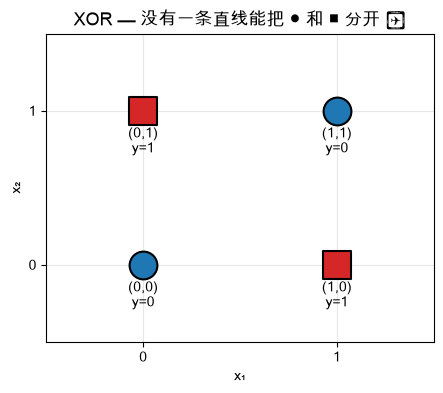

In [16]:
import matplotlib.pyplot as plt

# 可视化 XOR：一条直线不可能分开这两类
X = [(0,0), (0,1), (1,0), (1,1)]
y = [0, 1, 1, 0]

fig, ax = plt.subplots(figsize=(5, 4))
for (x1, x2), label in zip(X, y):
    marker = 'o' if label == 0 else 's'
    color = 'C0' if label == 0 else 'C3'
    ax.scatter(x1, x2, s=400, marker=marker, c=color, edgecolors='k', linewidths=1.5, zorder=5)
    ax.annotate(f'({x1},{x2})\ny={label}', (x1, x2), textcoords='offset points', xytext=(0, -30), ha='center', fontsize=10)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('XOR — 没有一条直线能把 ● 和 ■ 分开 ❌', fontsize=13)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.grid(True, alpha=0.3)
plt.show()

### 线性和非线性

- **线性**：能用一条直线分割的空间 → 单层感知机搞定
- **非线性**：必须用曲线分割的空间 → 需要**多层感知机**

这正是 1969 年 Minsky 在《Perceptrons》一书中指出的核心问题——导致 AI 第一次寒冬。

## 2.5 多层感知机

单层不行，但**叠加层**就可以了。XOR 可以用 AND、NAND、OR 组合实现：

```
    x₁ ──→ NAND ──→ s₁ ──→
                           AND ──→ y (XOR)
    x₂ ──→ OR   ──→ s₂ ──→

    第0层(输入)   第1层(隐藏)   第2层(输出)
```

这就是 **2 层感知机**。

In [17]:
# 用已有门电路组合实现 XOR
def XOR(x1, x2):
    s1 = NAND(x1, x2)
    s2 = OR(x1, x2)
    y = AND(s1, s2)
    return y

print('--- XOR ---')
print('(0,0)→', XOR(0,0), ' (0,1)→', XOR(0,1), ' (1,0)→', XOR(1,0), ' (1,1)→', XOR(1,1))
print()
print('期望:     0            1            1            0')
print('结果: ✅ 正确实现 XOR 门！')

--- XOR ---
(0,0)→ 0  (0,1)→ 1  (1,0)→ 1  (1,1)→ 0

期望:     0            1            1            0
结果: ✅ 正确实现 XOR 门！


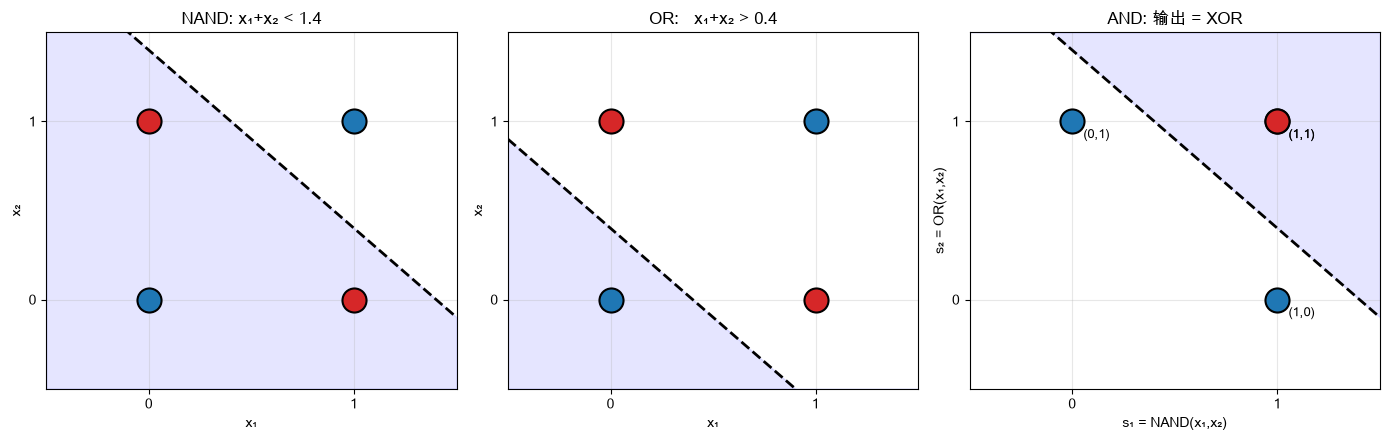

In [18]:
# 可视化：2 层感知机如何用两条直线分开 XOR
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for i, (name, w, b) in enumerate([
    ('NAND: x₁+x₂ < 1.4', np.array([-0.5, -0.5]), 0.7),
    ('OR:   x₁+x₂ > 0.4', np.array([0.5, 0.5]), -0.2),
]):
    ax = axes[i]
    for (x1, x2), label in zip(X, y):
        c = 'C0' if label == 0 else 'C3'
        ax.scatter(x1, x2, s=300, c=c, edgecolors='k', linewidths=1.5, zorder=5)
    xx = np.linspace(-0.5, 1.5, 100)
    yy = -(w[0] * xx + b) / w[1]
    ax.plot(xx, yy, 'k--', linewidth=2)
    ax.fill_between(xx, -0.5, yy, alpha=0.1, color='blue')
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.set_title(name, fontsize=12)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.grid(True, alpha=0.3)

# 第 2 层：AND，把隐藏层输出映射到最终结果
s1_vals = [NAND(x1, x2) for x1, x2 in X]
s2_vals = [OR(x1, x2) for x1, x2 in X]
ax = axes[2]
for i, (label, s1, s2) in enumerate(zip(y, s1_vals, s2_vals)):
    c = 'C0' if label == 0 else 'C3'
    ax.scatter(s1, s2, s=300, c=c, edgecolors='k', linewidths=1.5, zorder=5)
    ax.annotate(f'({s1},{s2})', (s1, s2), textcoords='offset points', xytext=(8, -12), fontsize=9)
xx = np.linspace(-0.5, 1.5, 100)
yy = -(0.5 * xx - 0.7) / 0.5
ax.plot(xx, yy, 'k--', linewidth=2)
ax.fill_between(xx, yy, 1.5, alpha=0.1, color='blue')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('s₁ = NAND(x₁,x₂)'); ax.set_ylabel('s₂ = OR(x₁,x₂)')
ax.set_title('AND: 输出 = XOR', fontsize=12)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 本章小结

| 概念 | 说明 |
|------|------|
| 感知机 | 接收多个输入，输出 0 或 1 |
| 权重 w | 控制输入信号的重要性 |
| 偏置 b | 控制神经元被激活的容易程度（b = -θ） |
| 单层感知机 | 只能分割**线性空间**（一条直线） |
| 多层感知机 | 可以分割**非线性空间** |
| XOR | 2 层感知机即可实现（NAND + OR → AND） |
| 理论能力 | 2 层感知机 + 非线性激活 = 可以表示任意函数 |

> **下一章预告**：感知机的权重是人工设定的。第 3 章「神经网络」将介绍**如何自动学习权重**——深度学习就此开始。